In [157]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt, ticker
%matplotlib inline

In [158]:
df = pd.read_csv("CreditScoring.csv")

In [159]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [160]:
df.columns = df.columns.str.lower()

In [161]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [162]:
# The original R script has the section for guides on how to clean data.
# https://github.com/gastonstat/CreditScoring/blob/master/Part1_CredScoring_Processing.R
# Also, there is an information about which columns are categorical and types of categories.
# In R indices start with 1.

In [163]:
status_values = {
    1: "ok",
    2: "default",
    0: "unk"
}

df.status = df.status.map(status_values)

home_values = {
    1: "rent",
    2: "owner",
    3: "private",
    4: "ignore",
    5: "parents",
    6: "other",
    0: "unk"
}

df.home = df.home.map(home_values)

marital_values = {
    1: "single",
    2: "married",
    3: "widow",
    4: "separated",
    5: "divorced",
    0: "unk"
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: "no",
    2: "yes",
    0: "unk"
}

df.records = df.records.map(records_values)

job_values = {
    1: "fixed",
    2: "partime",
    3: "freelance",
    4: "others",
    0: "unk"
}

df.job = df.job.map(job_values)

In [164]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,default,1,rent,60,39,married,no,fixed,69,92,0,0,900,1020
4451,ok,22,owner,60,46,married,no,fixed,60,75,3000,600,950,1263
4452,default,0,owner,24,37,married,no,partime,60,90,3500,0,500,963
4453,ok,0,rent,48,23,single,no,freelance,49,140,0,0,550,550


In [165]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [166]:
# As we can see the columns "income", "assets", "debt" have the max value of 999999999 which is considered as missing values.

In [167]:
value_to_replace = df.income.max()

In [168]:
value_to_replace

np.int64(99999999)

In [169]:
# Using the eq func that returns the column names containing the specific value
columns_with_missing = df.columns[df.eq(value_to_replace).any()].tolist()
for column in columns_with_missing:
    df[column] = df[column].replace(to_replace=value_to_replace, value=np.nan)

In [170]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [171]:
# Unknown values in status are not helping and can brick model. Remove the unknown values.
df = df[df.status != "unk"].reset_index(drop=True)

In [172]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [173]:
from sklearn.model_selection import train_test_split

# Split 60/20/20
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [174]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [175]:
y_train = (df_train.status == "default").astype("int").values
y_val = (df_val.status == "default").astype("int").values
y_test = (df_test.status == "default").astype("int").values

In [176]:
del df_train["status"]
del df_val["status"]
del df_test["status"]

In [177]:
# Decision trees are models, with logic similar to a bunch of if-else statements
def _asses_risk(client: dict) -> str:
    if client.get("records") == "yes":
        if client.get("job") == "parttime":
            return "default"
        else:
            return "ok"
    else:
        if client.get("assets") > 6000:
            return "ok"
        else:
            return "default"

In [178]:
# "Predict" clients from train dataset
risk = {}
for client in range(len(df_train.index)):
    risk.update({client: _asses_risk(df_train.iloc[client].to_dict())})
risk

{0: 'ok',
 1: 'ok',
 2: 'default',
 3: 'default',
 4: 'default',
 5: 'ok',
 6: 'default',
 7: 'default',
 8: 'default',
 9: 'default',
 10: 'ok',
 11: 'default',
 12: 'default',
 13: 'default',
 14: 'default',
 15: 'default',
 16: 'default',
 17: 'default',
 18: 'default',
 19: 'default',
 20: 'default',
 21: 'default',
 22: 'default',
 23: 'default',
 24: 'ok',
 25: 'default',
 26: 'default',
 27: 'default',
 28: 'ok',
 29: 'default',
 30: 'ok',
 31: 'ok',
 32: 'default',
 33: 'default',
 34: 'default',
 35: 'default',
 36: 'ok',
 37: 'ok',
 38: 'default',
 39: 'default',
 40: 'ok',
 41: 'default',
 42: 'default',
 43: 'default',
 44: 'default',
 45: 'default',
 46: 'default',
 47: 'ok',
 48: 'default',
 49: 'ok',
 50: 'default',
 51: 'ok',
 52: 'ok',
 53: 'default',
 54: 'default',
 55: 'default',
 56: 'default',
 57: 'default',
 58: 'default',
 59: 'default',
 60: 'default',
 61: 'ok',
 62: 'default',
 63: 'ok',
 64: 'ok',
 65: 'ok',
 66: 'ok',
 67: 'ok',
 68: 'default',
 69: 'defau

In [179]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [180]:
train_dicts = df_train.fillna(0).to_dict(orient="records")

In [181]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [182]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [183]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [184]:
val_dicts = df_val.fillna(0).to_dict(orient="records")
X_val = dv.transform(val_dicts)

In [185]:
y_pred = dt.predict_proba(X_val)

In [186]:
y_pred = y_pred[:, 1]

In [187]:
roc_auc_score(y_val, y_pred)

0.645155724007653

In [188]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

In [189]:
# When the model is so drastically different this is called "overfitting".
# This is happening because model "memorizes" data. And when it sees a new sample, that is unknown for model, the results are sad.
# So the model creates rules just for one sample, that will not be used in any other prediction.
# The root of the problem is that the tree, which was created, is very deep.
# The solution is to restrict the depth of the tree, for example depth = 3.

In [190]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [191]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7389079944782155

In [192]:
# The score improved drastically

In [193]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

0.7761016984958594

In [194]:
# Now the ratio between "ideal" dataset and validation dataset is not very big.

In [195]:
from sklearn.tree import export_text

# Visualize the tree
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0



In [196]:
# This is "infinite" tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- income <= 20.00
|   |   |   |   |   |--- seniority <= 1.50
|   |   |   |   |   |   |--- home=parents <= 0.50
|   |   |   |   |   |   |   |--- seniority <= 0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- seniority >  0.50
|   |   |   |   |   |   |   |   |--- price <= 1457.50
|   |   |   |   |   |   |   |   |   |--- expenses <= 55.00
|   |   |   |   |   |   |   |   |   |   |--- home=other <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |   |--- home=other >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- expenses >  55.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- price >  1457.50
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- h

In [197]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [198]:
# Decision tree - example with small dataset

In [199]:
data = [
    [8000, "default"],
    [2000, "default"],
    [0, "default"],
    [5000, "ok"],
    [5000, "ok"],
    [4000, "ok"],
    [9000, "ok"],
    [3000, "default"],
]

df_example = pd.DataFrame(data, columns=["assets", "status"])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [200]:
# Condition - assets > T (T - threshold)
# The task is to find the best T value
# Node condition - o
# Split - the decision
# Leaf - the non-depth decision
# leaf-left <- o -> leaf-right   <<- this is called split, because we are splitting the dataset into two parts
# Right - True
# Left - False

In [201]:
df_example.sort_values("assets")

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


In [202]:
# Potential thresholds are - [2000, 3000, 4000, 5000, 8000]

In [203]:
thresholds = [0, 2000, 3000, 4000, 5000, 8000]

In [204]:
# Finding the best threshold

In [205]:
from IPython.display import display

for threshold in thresholds:
    print(threshold)
    print("=====")
    df_left = df_example[df_example.assets <= threshold]
    df_right = df_example[df_example.assets > threshold]
    print("df_left")
    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    print("=====")
    print("df_right")
    display(df_right)
    print(df_right.status.value_counts(normalize=True))


0
=====
df_left


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64
2000
=====
df_left


,assets,status
1,2000,default
2,0,default


status
default    1.0
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64
3000
=====
df_left


,assets,status
1,2000,default
2,0,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64
4000
=====
df_left


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64
5000
=====
df_left


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
8000
=====
df_left


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64
=====
df_right


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64


In [206]:
# In order to find the best threshold we need to calculate the misclassification rate

In [207]:
threshold = 4000
print(threshold)
print("=====")
df_left = df_example[df_example.assets <= threshold]
df_right = df_example[df_example.assets > threshold]
print("df_left")
display(df_left)
print(df_left.status.value_counts(normalize=True))
print("=====")
print("df_right")
display(df_right)
print(df_right.status.value_counts(normalize=True))

4000
=====
df_left


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64


In [208]:
# Misclassification rate - what if we predict that all values in both df_left is false and df_right is true (in our credit score rate df_left == default and df_right == ok)
# In case of threshold of 4000 the misclassification rate is 25%
# 2000 == default -> hit
# 0    == default -> hit
# 4000 != default -> miss
# 3000 == default -> hit
# 3/4 == 75% hit rate
# misclassification rate (mcr) df_left = 100% - hit rate = 25% for df_left
# 8000 != ok -> miss
# 5000 == ok -> hit
# 4000 == ok -> hit
# 3000 == ok -> hit
# 3/4 == 75% hit rate
# misclassification rate (mcr) df_right = 100% - hit rate = 25% for df_right
# avg(mcr_df_left, mcr_df_right) = 25%
# In most cases the trees" algorithm is using weightened average of mcr

In [209]:
from IPython.display import display

for threshold in thresholds:
    print(f"{threshold=}")
    print("=====")
    df_left = df_example[df_example.assets <= threshold]
    df_right = df_example[df_example.assets > threshold]
    print("df_left")
    print(df_left.status.value_counts(normalize=True))
    display(df_left)
    print("df_right")
    print(df_right.status.value_counts(normalize=True))
    display(df_right)

threshold=0
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,status
2,0,default


df_right
status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


threshold=2000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default


df_right
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


threshold=3000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default
7,3000,default


df_right
status
ok         0.8
default    0.2
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


threshold=4000
=====
df_left
status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


df_right
status
ok         0.75
default    0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


threshold=5000
=====
df_left
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


df_right
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


threshold=8000
=====
df_left
status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


df_right
status
ok    1.0
Name: proportion, dtype: float64


,assets,status
6,9000,ok


In [210]:
# MCR is also called impurity
# Table of values for assets
# threshold | df_left | impurity_left | df_right | impurity_right | avg
# ----------|---------|---------------|----------|----------------|-----
#      0    | default |       0%      |    ok    |      43%       | 21%
# ----------|         |---------------|          |----------------|-----
#    2000   |         |       0%      |          |      33%       | 16%
# ----------|         |---------------|          |----------------|-----
#    3000   |         |       0%      |          |      20%       | 10%  <---- best one for assets
# ----------|         |---------------|          |----------------|-----
#    4000   |         |      25%      |          |      25%       | 25%
# ----------|         |---------------|          |----------------|-----
#    5000   |         |      50%      |          |      50%       | 50%
# ----------|         |---------------|          |----------------|-----
#    5000   |         |      43%      |          |       0%       | 21%
# ----------|---------|---------------|----------|----------------|-----
# The best split is threshold == 3000, because average mcr is 10%

In [211]:
# Multiple features

In [212]:
data = [
    [8000, 3000, "default"],
    [2000, 1000, "default"],
    [0, 1000, "default"],
    [5000, 1000, "ok"],
    [5000, 1000, "ok"],
    [4000, 1000, "ok"],
    [9000, 500, "ok"],
    [3000, 2000, "default"],
]

df_example = pd.DataFrame(data, columns=["assets", "debt", "status"])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [213]:
df_example.sort_values("debt")

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,2000,default
0,8000,3000,default


In [214]:
feature_thresholds = {"assets": [0, 2000, 3000, 4000, 5000, 8000], "debt": [500, 1000, 2000]}

In [215]:
for feature, thresholds in feature_thresholds.items():
    print("=====")
    print(f"working with feature {feature}")
    print("=====")
    for threshold in thresholds:
        print(f"{threshold=}")
        print("=====")
        df_left = df_example[df_example[feature] <= threshold]
        df_right = df_example[df_example[feature] > threshold]
        print("df_left")
        print(df_left.status.value_counts(normalize=True))
        display(df_left)
        print("df_right")
        print(df_right.status.value_counts(normalize=True))
        display(df_right)

=====
working with feature assets
=====
threshold=0
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
2,0,1000,default


df_right
status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


threshold=2000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default


df_right
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


threshold=3000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,2000,default


df_right
status
ok         0.8
default    0.2
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


threshold=4000
=====
df_left
status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,2000,default


df_right
status
ok         0.75
default    0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


threshold=5000
=====
df_left
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


df_right
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


threshold=8000
=====
df_left
status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


df_right
status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


=====
working with feature debt
=====
threshold=500
=====
df_left
status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


df_right
status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


threshold=1000
=====
df_left
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


df_right
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
7,3000,2000,default


threshold=2000
=====
df_left
status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


df_right
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


In [216]:
# Table of values for debt
# threshold | df_left | impurity_left | df_right | impurity_right | avg
# ----------|---------|---------------|----------|----------------|-----
#    500    |   ok    |       0%      |  default |      43%       | 21%
# ----------|         |---------------|          |----------------|-----
#    1000   |         |      33%      |          |      0%        | 16%  <---- best one for debt
# ----------|         |---------------|          |----------------|-----
#    2000   |         |      43%      |          |      0%        | 21%
# ----------|         |---------------|          |----------------|-----

In [217]:
# The best avg mcr for assets is 10% and for debt is 16%. Which means, that for out model we should use assets for split
# assets > 3000 is the best split among all the features and their values
# Pseudolanguage algorithm:
# for f in features:
#   thresholds = find_all_thresholds(f)
#   for threshold in thresholds:
#     split_dataset(feature > threshold)
#     calculate_impurity(split_dataset)
#     calculate_avg(impurity)
# select_the_condition_with_lowest_impurity()
# This algorithm can be used recursively with max number of iterations == max_depth
# We can split our datasets as much as we want, but we need to eventually stop in order not to be the victim of overfitting
# Criteria for stopping splitting the current dataset (df_left, df_left_left, df_left_right, df_right_left_right and so on):
# - group is already pure;
# - max_depth is the limit;
# - len(group) is relatively small (stop when len <= 5);

In [218]:
# Parameter tuning

In [219]:
# Main parameters to select are:
# - max_depth;
# - min_samples_leaf;

In [220]:
for depth in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print(f"{str(depth):4} -> auc={auc:.3f}")

1    -> auc=0.606
2    -> auc=0.669
3    -> auc=0.739
4    -> auc=0.761
5    -> auc=0.766
6    -> auc=0.750
10   -> auc=0.679
15   -> auc=0.666
20   -> auc=0.656
None -> auc=0.665


In [221]:
# The less depth the better, but auc must be considered
# However let's check the correlation between depth and leaf sample (the minimum amount of records in each node)

In [222]:
for depth in [4, 5, 6]:
    for leaf in [1, 2, 3, 4, 5, 6, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        print(f"{str(depth):4} + {leaf:4} -> auc={auc:.3f}")

4    +    1 -> auc=0.761
4    +    2 -> auc=0.761
4    +    3 -> auc=0.761
4    +    4 -> auc=0.761
4    +    5 -> auc=0.761
4    +    6 -> auc=0.761
4    +   10 -> auc=0.761
4    +   15 -> auc=0.764
4    +   20 -> auc=0.761
4    +  100 -> auc=0.756
4    +  200 -> auc=0.747
4    +  500 -> auc=0.680
5    +    1 -> auc=0.767
5    +    2 -> auc=0.766
5    +    3 -> auc=0.766
5    +    4 -> auc=0.767
5    +    5 -> auc=0.768
5    +    6 -> auc=0.768
5    +   10 -> auc=0.762
5    +   15 -> auc=0.772
5    +   20 -> auc=0.774
5    +  100 -> auc=0.763
5    +  200 -> auc=0.759
5    +  500 -> auc=0.680
6    +    1 -> auc=0.761
6    +    2 -> auc=0.759
6    +    3 -> auc=0.752
6    +    4 -> auc=0.763
6    +    5 -> auc=0.763
6    +    6 -> auc=0.764
6    +   10 -> auc=0.778
6    +   15 -> auc=0.785
6    +   20 -> auc=0.774
6    +  100 -> auc=0.776
6    +  200 -> auc=0.768
6    +  500 -> auc=0.680


In [223]:
scores = []
for depth in [4, 5, 6]:
    for leaf in [1, 2, 3, 4, 5, 6, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((depth, leaf, auc))
df_scores = pd.DataFrame(scores, columns=["depth", "leaf", "auc"])
df_scores[df_scores.auc == max(df_scores.auc)]

,depth,leaf,auc
31,6,15,0.785471


In [224]:
df_scores.sort_values(by="auc", ascending=False)

,depth,leaf,auc
31,6,15,0.785471
30,6,10,0.778299
33,6,100,0.776434
20,5,20,0.774028
32,6,20,0.773337
19,5,15,0.771806
34,6,200,0.768267
16,5,5,0.768173
17,5,6,0.768173
12,5,1,0.766938


In [225]:
df_scores_pivot = df_scores.pivot(index="leaf", columns=["depth"], values="auc")
df_scores_pivot.round(3)

depth,4,5,6
leaf,,,
1,0.761,0.767,0.751
2,0.761,0.766,0.754
3,0.761,0.767,0.759
4,0.761,0.766,0.763
5,0.761,0.768,0.762
6,0.761,0.768,0.764
10,0.761,0.762,0.778
15,0.764,0.772,0.785
20,0.761,0.774,0.773


<Axes: xlabel='depth', ylabel='leaf'>

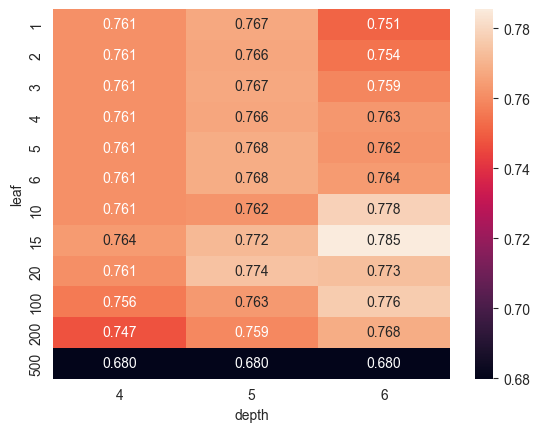

In [226]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

<Axes: xlabel='depth', ylabel='leaf'>

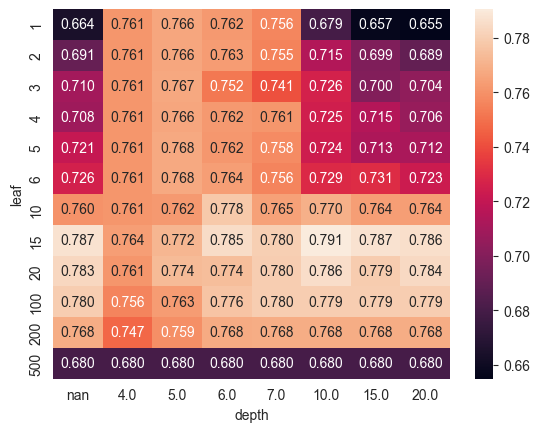

In [227]:
scores = []
for depth in [4, 5, 6, 7, 10, 15, 20, None]:
    for leaf in [1, 2, 3, 4, 5, 6, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((depth, leaf, auc))
df_scores = pd.DataFrame(scores, columns=["depth", "leaf", "auc"])
df_scores_pivot = df_scores.pivot(index="leaf", columns=["depth"], values="auc")
df_scores_pivot.round(3)
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [228]:
# Using the model with best combo
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [229]:
# Random forest is a process of evaluating the decision made by each binary tree and merging the results together.
# Random - because each of binary tree has different random set of features but same number of features.
# E.g. model g1 has 3 features (time, date and temperature), model g2 has also 3 but different (time, month and temperature) and so on.
# The result of all the trees is calculated as an average
# 1/n * SUM(g1,...,gn)

In [230]:
from sklearn.ensemble import RandomForestClassifier

In [231]:
rf = RandomForestClassifier(n_estimators=10,
                            random_state=1)  # 10 models to train, random seed = 1 means estimators will always have same feature set
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [232]:
y_pred = rf.predict_proba(X_val)[:, 1]

In [233]:
roc_auc_score(y_val, y_pred)

0.7744726453706618

In [234]:
rf.predict_proba(X_val[[0]])

array([[0.9, 0.1]])

In [235]:
scores = []
for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [236]:
df_scores = pd.DataFrame(scores, columns=["n_of_estimators", "auc"])

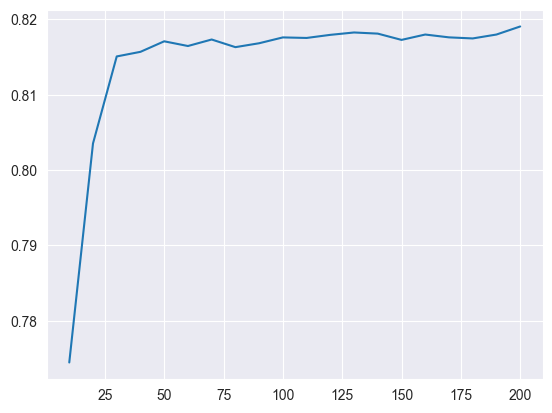

In [237]:
plt.plot(df_scores.n_of_estimators, df_scores.auc)

In [238]:
# Best value for number of estimators is 100 according to graph
n_estimators = 100

In [239]:
# Determining the best max depth value
scores = []
depth_range = [5, 10, 15]
for d in depth_range:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [240]:
df_scores = pd.DataFrame(scores, columns=["max_depth", "n_of_estimators", "auc"])
df_scores

,max_depth,n_of_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878
5,5,60,0.801167
6,5,70,0.802251
7,5,80,0.803244
8,5,90,0.803616
9,5,100,0.804452


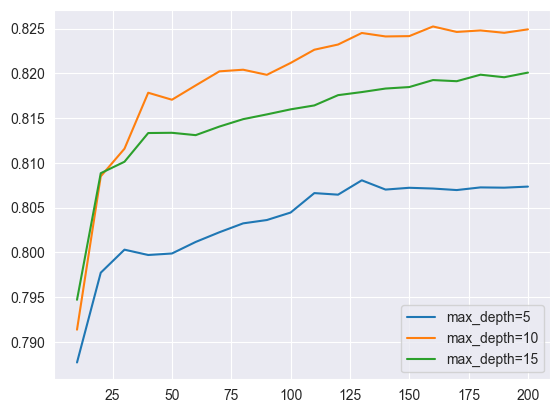

In [241]:
for d in depth_range:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_of_estimators, df_subset.auc, label=f"max_depth={d}")
plt.legend()

In [242]:
# Best max depth value according to graph
max_depth = 10

In [243]:
# Determining the best leaf count value
scores = []
leaf_count = [1, 3, 5, 10, 50]
for s in leaf_count:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, random_state=1, min_samples_leaf=s)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [244]:
df_scores = pd.DataFrame(scores, columns=["leaf_count", "n_of_estimators", "auc"])
df_scores

,leaf_count,n_of_estimators,auc
0,1,10,0.791365
1,1,20,0.808496
2,1,30,0.811584
3,1,40,0.817839
4,1,50,0.817058
...,...,...,...
95,50,160,0.805929
96,50,170,0.805172
97,50,180,0.805324
98,50,190,0.805596


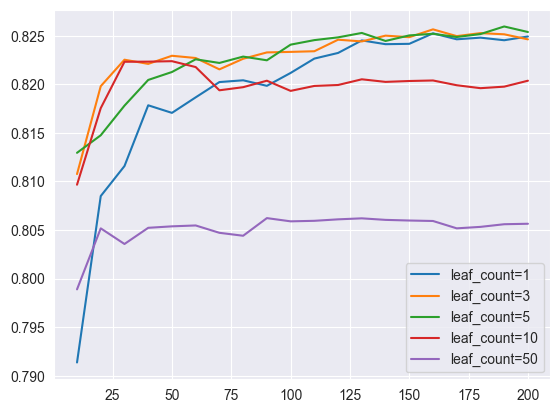

In [245]:
for s in leaf_count:
    df_subset = df_scores[df_scores.leaf_count == s]
    plt.plot(df_subset.n_of_estimators, df_subset.auc, label=f"leaf_count={s}")
plt.legend()

In [246]:
# Best value of min_sample_leaf is 3 according to graph
leaf_count = 3

In [247]:
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=leaf_count, random_state=1,
                            n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)

In [248]:
# Gradient Boost
# When the model uses previous model as source of errors and corrects them
# g1 -> predicts -> some errors -> g2 trains on original dataset and fixes errors of g1 -> predicts -> some errors -> ... -> and so on
# All those models are trained in sequence
# g1 -> g2 + g1 errors -> g3 + (g1 + g2 errors) -> ... -> gn + (sum(gn-1) errors)

In [249]:
import xgboost as xgb

In [250]:
# Create a D-matrix - a series of trees to allow gradient boosting on them
features = dv.get_feature_names_out()
dtrain = xgb.DMatrix(data=X_train, label=y_train, feature_names=[feature for feature in features])
dval = xgb.DMatrix(data=X_val, label=y_val, feature_names=[feature for feature in features])

In [251]:
# Train the gradient boost
# Specify the parameters
xgb_params = {
    "eta": 0.3,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, num_boost_round=10)

In [252]:
y_pred = model.predict(dval)

In [253]:
roc_auc_score(y_val, y_pred)

0.8118506454190986

In [254]:
# XGBoost offers evaluation right after the training is completed

In [255]:
watchlist = [(dtrain, "train"), (dval, "eval")]

In [256]:
# Train the gradient boost
# Specify the parameters
xgb_params = {
    "eta": 0.3,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
evals_result = {}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Using the 200 rounds leads to overfitting with our dataset

[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.89089	eval-auc:0.79060
[2]	train-auc:0.90503	eval-auc:0.78881
[3]	train-auc:0.91573	eval-auc:0.79997
[4]	train-auc:0.92429	eval-auc:0.80367
[5]	train-auc:0.92969	eval-auc:0.80822
[6]	train-auc:0.93630	eval-auc:0.81043
[7]	train-auc:0.94073	eval-auc:0.81173
[8]	train-auc:0.94748	eval-auc:0.81328
[9]	train-auc:0.95012	eval-auc:0.81185
[10]	train-auc:0.95512	eval-auc:0.81115
[11]	train-auc:0.95661	eval-auc:0.81133
[12]	train-auc:0.95936	eval-auc:0.81433
[13]	train-auc:0.96146	eval-auc:0.81863
[14]	train-auc:0.96427	eval-auc:0.81872
[15]	train-auc:0.96767	eval-auc:0.81993
[16]	train-auc:0.96975	eval-auc:0.81863
[17]	train-auc:0.97158	eval-auc:0.82002
[18]	train-auc:0.97336	eval-auc:0.82015
[19]	train-auc:0.97499	eval-auc:0.81979
[20]	train-auc:0.97648	eval-auc:0.81877
[21]	train-auc:0.97773	eval-auc:0.81969
[22]	train-auc:0.97842	eval-auc:0.81880
[23]	train-auc:0.97902	eval-auc:0.81805
[24]	train-auc:0.98102	eval-auc:0.81686
[25]	train

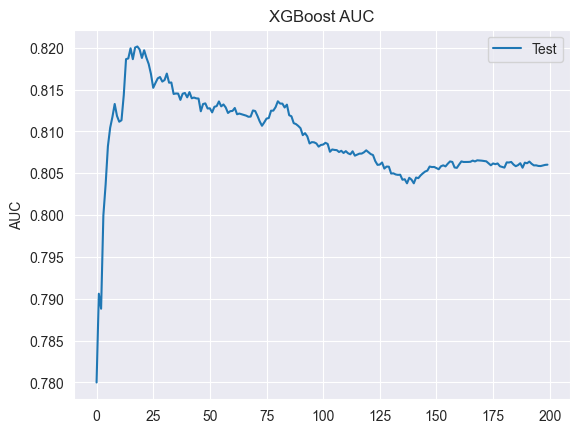

In [257]:
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()

In [258]:
# The best auc is ~20 iterations according to graph

In [259]:
# XGB parameter tuning
xgb_params = {
    "eta": 0.3,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
# In-depth guide on parameters
# 1. ETA - the Learning Rate
# How much weight does the second model has when correcting the result of the first model.
# Value of 1.0 means that g2 will try to correct 100% of failed predictions of model g1
# This parameter is also known as size of step

[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.89089	eval-auc:0.79060
[2]	train-auc:0.90503	eval-auc:0.78881
[3]	train-auc:0.91573	eval-auc:0.79997
[4]	train-auc:0.92429	eval-auc:0.80367
[5]	train-auc:0.92969	eval-auc:0.80822
[6]	train-auc:0.93630	eval-auc:0.81043
[7]	train-auc:0.94073	eval-auc:0.81173
[8]	train-auc:0.94748	eval-auc:0.81328
[9]	train-auc:0.95012	eval-auc:0.81185
[10]	train-auc:0.95512	eval-auc:0.81115
[11]	train-auc:0.95661	eval-auc:0.81133
[12]	train-auc:0.95936	eval-auc:0.81433
[13]	train-auc:0.96146	eval-auc:0.81863
[14]	train-auc:0.96427	eval-auc:0.81872
[15]	train-auc:0.96767	eval-auc:0.81993
[16]	train-auc:0.96975	eval-auc:0.81863
[17]	train-auc:0.97158	eval-auc:0.82002
[18]	train-auc:0.97336	eval-auc:0.82015
[19]	train-auc:0.97499	eval-auc:0.81979
[20]	train-auc:0.97648	eval-auc:0.81877
[21]	train-auc:0.97773	eval-auc:0.81969
[22]	train-auc:0.97842	eval-auc:0.81880
[23]	train-auc:0.97902	eval-auc:0.81805
[24]	train-auc:0.98102	eval-auc:0.81686
[25]	train

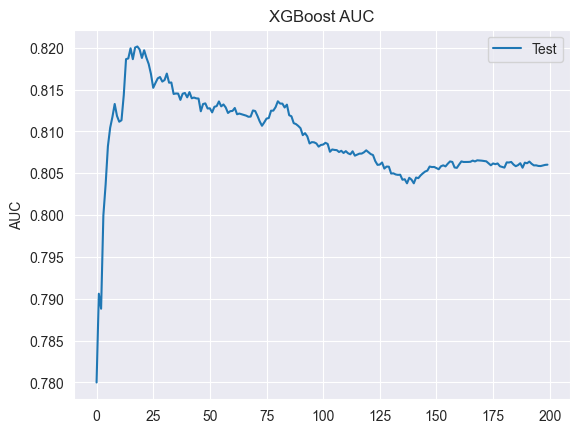

In [260]:
evals_result = {}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()

In [261]:
# Dictionary for plotting the different eta values with eval scores
scores = {}

In [262]:
scores[xgb_params["eta"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.91112	eval-auc:0.79363
[2]	train-auc:0.93016	eval-auc:0.79355
[3]	train-auc:0.94222	eval-auc:0.79582
[4]	train-auc:0.95306	eval-auc:0.79066
[5]	train-auc:0.96126	eval-auc:0.78834
[6]	train-auc:0.96641	eval-auc:0.78932
[7]	train-auc:0.97629	eval-auc:0.78677
[8]	train-auc:0.97850	eval-auc:0.78933
[9]	train-auc:0.98138	eval-auc:0.78874
[10]	train-auc:0.98555	eval-auc:0.78862
[11]	train-auc:0.98908	eval-auc:0.78675
[12]	train-auc:0.99007	eval-auc:0.78518
[13]	train-auc:0.99175	eval-auc:0.78062
[14]	train-auc:0.99394	eval-auc:0.78388
[15]	train-auc:0.99523	eval-auc:0.78400
[16]	train-auc:0.99644	eval-auc:0.78415
[17]	train-auc:0.99683	eval-auc:0.78422
[18]	train-auc:0.99836	eval-auc:0.78576
[19]	train-auc:0.99919	eval-auc:0.78299
[20]	train-auc:0.99943	eval-auc:0.78606
[21]	train-auc:0.99971	eval-auc:0.78711
[22]	train-auc:0.99983	eval-auc:0.78810
[23]	train-auc:0.99988	eval-auc:0.79097
[24]	train-auc:0.99997	eval-auc:0.79085
[25]	train

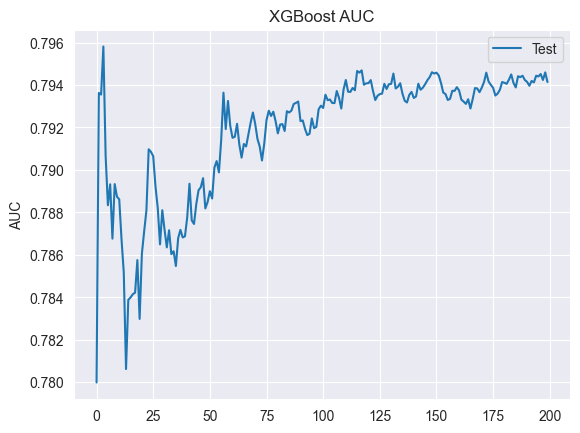

In [263]:
evals_result = {}
xgb_params = {
    "eta": 1.0,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()

In [264]:
scores[xgb_params["eta"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

In [265]:
scores[1.0]

,num_iterations,train_auc,test_auc
0,0,0.866526,0.779991
1,1,0.911118,0.793626
2,2,0.930155,0.793551
3,3,0.942216,0.795815
4,4,0.953058,0.790657
...,...,...,...
195,195,1.000000,0.794404
196,196,1.000000,0.794516
197,197,1.000000,0.794238
198,198,1.000000,0.794595


[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.90653	eval-auc:0.80330
[2]	train-auc:0.92410	eval-auc:0.81117
[3]	train-auc:0.94468	eval-auc:0.80769
[4]	train-auc:0.95284	eval-auc:0.80459
[5]	train-auc:0.95868	eval-auc:0.81019
[6]	train-auc:0.96427	eval-auc:0.81521
[7]	train-auc:0.97405	eval-auc:0.80461
[8]	train-auc:0.97844	eval-auc:0.80407
[9]	train-auc:0.98129	eval-auc:0.80115
[10]	train-auc:0.98410	eval-auc:0.79985
[11]	train-auc:0.98725	eval-auc:0.79702
[12]	train-auc:0.98986	eval-auc:0.79760
[13]	train-auc:0.99062	eval-auc:0.79626
[14]	train-auc:0.99340	eval-auc:0.79390
[15]	train-auc:0.99566	eval-auc:0.79585
[16]	train-auc:0.99597	eval-auc:0.79627
[17]	train-auc:0.99721	eval-auc:0.79410
[18]	train-auc:0.99764	eval-auc:0.79497
[19]	train-auc:0.99852	eval-auc:0.79375
[20]	train-auc:0.99867	eval-auc:0.79389
[21]	train-auc:0.99932	eval-auc:0.79553
[22]	train-auc:0.99939	eval-auc:0.79484
[23]	train-auc:0.99962	eval-auc:0.79455
[24]	train-auc:0.99976	eval-auc:0.79407
[25]	train

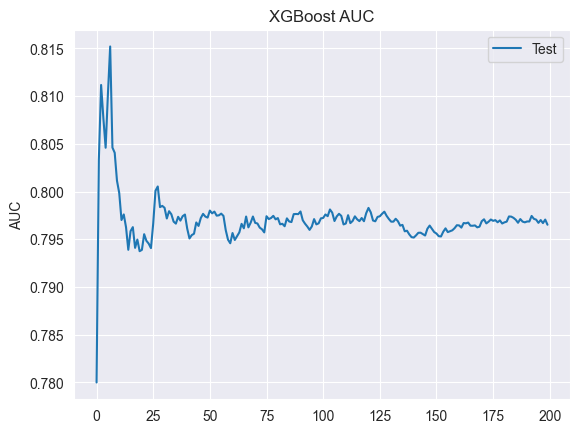

In [266]:
evals_result = {}
xgb_params = {
    "eta": 0.9,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["eta"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

In [267]:
scores[0.9]

,num_iterations,train_auc,test_auc
0,0,0.866526,0.779991
1,1,0.906529,0.803299
2,2,0.924104,0.811173
3,3,0.944678,0.807694
4,4,0.952844,0.804594
...,...,...,...
195,195,1.000000,0.796720
196,196,1.000000,0.797017
197,197,1.000000,0.796696
198,198,1.000000,0.797065


[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.87134	eval-auc:0.77310
[2]	train-auc:0.88925	eval-auc:0.79150
[3]	train-auc:0.89886	eval-auc:0.79550
[4]	train-auc:0.90151	eval-auc:0.79662
[5]	train-auc:0.90462	eval-auc:0.79276
[6]	train-auc:0.90854	eval-auc:0.79724
[7]	train-auc:0.91030	eval-auc:0.79964
[8]	train-auc:0.91424	eval-auc:0.80459
[9]	train-auc:0.91658	eval-auc:0.80463
[10]	train-auc:0.91936	eval-auc:0.80573
[11]	train-auc:0.92040	eval-auc:0.80645
[12]	train-auc:0.92348	eval-auc:0.80848
[13]	train-auc:0.92572	eval-auc:0.81029
[14]	train-auc:0.92983	eval-auc:0.81126
[15]	train-auc:0.93128	eval-auc:0.81241
[16]	train-auc:0.93229	eval-auc:0.81389
[17]	train-auc:0.93513	eval-auc:0.81584
[18]	train-auc:0.93761	eval-auc:0.81585
[19]	train-auc:0.93848	eval-auc:0.81544
[20]	train-auc:0.94007	eval-auc:0.81551
[21]	train-auc:0.94213	eval-auc:0.81619
[22]	train-auc:0.94270	eval-auc:0.81681
[23]	train-auc:0.94503	eval-auc:0.81645
[24]	train-auc:0.94607	eval-auc:0.81630
[25]	train

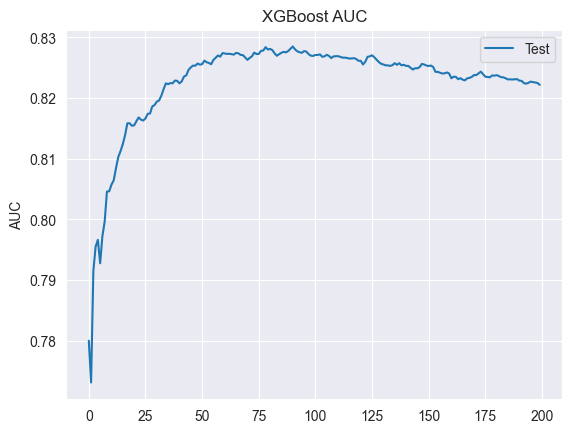

In [268]:
evals_result = {}
xgb_params = {
    "eta": 0.1,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["eta"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

In [269]:
scores[0.1]

,num_iterations,train_auc,test_auc
0,0,0.866526,0.779991
1,1,0.871342,0.773101
2,2,0.889254,0.791498
3,3,0.898860,0.795500
4,4,0.901510,0.796623
...,...,...,...
195,195,0.999301,0.822713
196,196,0.999317,0.822646
197,197,0.999343,0.822579
198,198,0.999352,0.822501


[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.87006	eval-auc:0.77407
[2]	train-auc:0.87207	eval-auc:0.77802
[3]	train-auc:0.87511	eval-auc:0.78338
[4]	train-auc:0.87683	eval-auc:0.78777
[5]	train-auc:0.88634	eval-auc:0.79497
[6]	train-auc:0.89382	eval-auc:0.79701
[7]	train-auc:0.89629	eval-auc:0.79748
[8]	train-auc:0.89806	eval-auc:0.79588
[9]	train-auc:0.90037	eval-auc:0.79457
[10]	train-auc:0.90122	eval-auc:0.79380
[11]	train-auc:0.90417	eval-auc:0.79828
[12]	train-auc:0.90587	eval-auc:0.79626
[13]	train-auc:0.90736	eval-auc:0.79824
[14]	train-auc:0.90814	eval-auc:0.79858
[15]	train-auc:0.90940	eval-auc:0.80111
[16]	train-auc:0.91080	eval-auc:0.80232
[17]	train-auc:0.91290	eval-auc:0.80415
[18]	train-auc:0.91397	eval-auc:0.80566
[19]	train-auc:0.91559	eval-auc:0.80747
[20]	train-auc:0.91725	eval-auc:0.80696
[21]	train-auc:0.91858	eval-auc:0.80643
[22]	train-auc:0.91963	eval-auc:0.80619
[23]	train-auc:0.92136	eval-auc:0.80766
[24]	train-auc:0.92234	eval-auc:0.80693
[25]	train

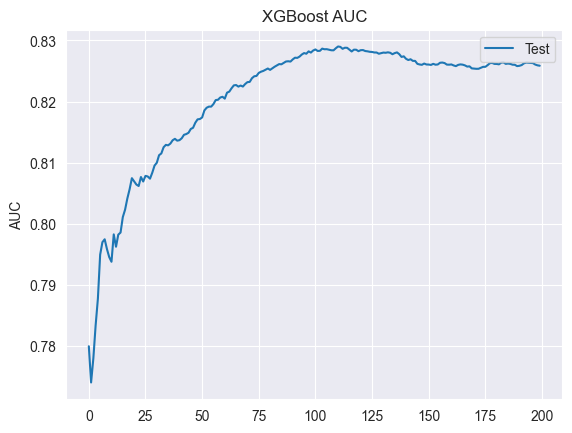

In [270]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["eta"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.86661	eval-auc:0.77982
[2]	train-auc:0.86677	eval-auc:0.77977
[3]	train-auc:0.86872	eval-auc:0.77855
[4]	train-auc:0.86939	eval-auc:0.77836
[5]	train-auc:0.87039	eval-auc:0.77827
[6]	train-auc:0.87020	eval-auc:0.77800
[7]	train-auc:0.87070	eval-auc:0.77791
[8]	train-auc:0.87085	eval-auc:0.77867
[9]	train-auc:0.87176	eval-auc:0.77841
[10]	train-auc:0.87211	eval-auc:0.77828
[11]	train-auc:0.87322	eval-auc:0.78298
[12]	train-auc:0.87353	eval-auc:0.78320
[13]	train-auc:0.87385	eval-auc:0.78317
[14]	train-auc:0.87391	eval-auc:0.78328
[15]	train-auc:0.87412	eval-auc:0.78300
[16]	train-auc:0.87451	eval-auc:0.78362
[17]	train-auc:0.87499	eval-auc:0.78539
[18]	train-auc:0.87626	eval-auc:0.78605
[19]	train-auc:0.87572	eval-auc:0.78710
[20]	train-auc:0.87621	eval-auc:0.78749
[21]	train-auc:0.87679	eval-auc:0.78833
[22]	train-auc:0.88192	eval-auc:0.79221
[23]	train-auc:0.88392	eval-auc:0.79427
[24]	train-auc:0.88471	eval-auc:0.79493
[25]	train

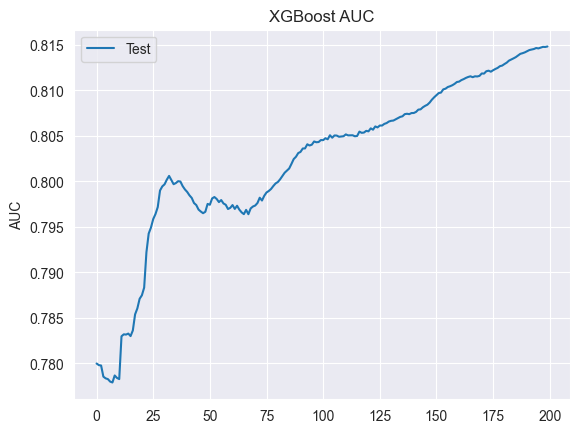

In [127]:
evals_result = {}
xgb_params = {
    "eta": 0.01,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["eta"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

In [129]:
scores[0.01]

,num_iterations,train_auc,test_auc
0,0,0.866526,0.779991
1,1,0.866612,0.779816
2,2,0.866774,0.779767
3,3,0.868725,0.778547
4,4,0.869394,0.778360
...,...,...,...
195,195,0.938535,0.814624
196,196,0.938784,0.814702
197,197,0.938938,0.814793
198,198,0.939124,0.814781


In [272]:
scores.keys()

dict_keys([0.3, 1.0, 0.9, 0.1, 0.05])

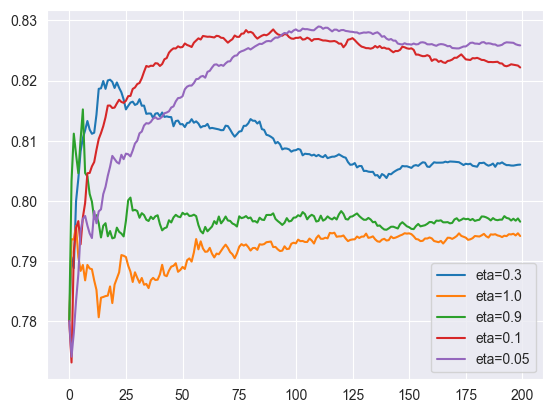

In [273]:
for key, df_scores in scores.items():
    plt.plot(df_scores["num_iterations"], df_scores["test_auc"], label=f"eta={key}")
plt.legend()

In [274]:
# This shows how does the learning rate affects auc
# According to graph the worst value is 1.0, then 0.9
# The best values are 0.1 at ~85 iterations and 0.05 at ~110 iterations

In [275]:
# Finding the best combo of eta/auc/iterations
max_auc = 0.0
best_value = "", 0.0, 0

In [276]:
for key, df_scores in scores.items():
    for i in range(len(df_scores["num_iterations"])):
        if df_scores["test_auc"][i] > max_auc:
            max_auc = df_scores["test_auc"][i]
            best_value = key, max_auc, i + 1
best_value

(0.05, np.float64(0.8290032936959628), 111)

In [ ]:
# Best value is
# eta = 0.05, auc = 0.8290032936959628, num_iterations = 111

In [279]:
scores = {}

In [280]:
# Tuning the max_depth parameter
# 2.

[0]	train-auc:0.86653	eval-auc:0.77999
[1]	train-auc:0.87006	eval-auc:0.77407
[2]	train-auc:0.87207	eval-auc:0.77802
[3]	train-auc:0.87511	eval-auc:0.78338
[4]	train-auc:0.87683	eval-auc:0.78777
[5]	train-auc:0.88634	eval-auc:0.79497
[6]	train-auc:0.89382	eval-auc:0.79701
[7]	train-auc:0.89629	eval-auc:0.79748
[8]	train-auc:0.89806	eval-auc:0.79588
[9]	train-auc:0.90037	eval-auc:0.79457
[10]	train-auc:0.90122	eval-auc:0.79380
[11]	train-auc:0.90417	eval-auc:0.79828
[12]	train-auc:0.90587	eval-auc:0.79626
[13]	train-auc:0.90736	eval-auc:0.79824
[14]	train-auc:0.90814	eval-auc:0.79858
[15]	train-auc:0.90940	eval-auc:0.80111
[16]	train-auc:0.91080	eval-auc:0.80232
[17]	train-auc:0.91290	eval-auc:0.80415
[18]	train-auc:0.91397	eval-auc:0.80566
[19]	train-auc:0.91559	eval-auc:0.80747
[20]	train-auc:0.91725	eval-auc:0.80696
[21]	train-auc:0.91858	eval-auc:0.80643
[22]	train-auc:0.91963	eval-auc:0.80619
[23]	train-auc:0.92136	eval-auc:0.80766
[24]	train-auc:0.92234	eval-auc:0.80693
[25]	train

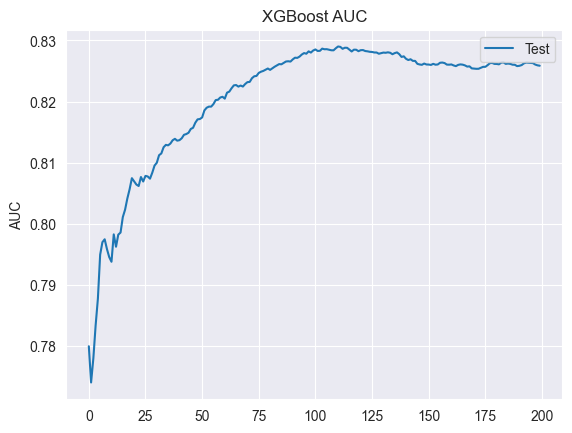

In [281]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 6,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["max_depth"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

[0]	train-auc:0.77610	eval-auc:0.73891
[1]	train-auc:0.77718	eval-auc:0.73992
[2]	train-auc:0.81066	eval-auc:0.77631
[3]	train-auc:0.81005	eval-auc:0.77593
[4]	train-auc:0.82562	eval-auc:0.77768
[5]	train-auc:0.82506	eval-auc:0.77525
[6]	train-auc:0.82719	eval-auc:0.77402
[7]	train-auc:0.83133	eval-auc:0.77588
[8]	train-auc:0.83229	eval-auc:0.77892
[9]	train-auc:0.83233	eval-auc:0.77753
[10]	train-auc:0.83304	eval-auc:0.77603
[11]	train-auc:0.83526	eval-auc:0.77748
[12]	train-auc:0.83557	eval-auc:0.77641
[13]	train-auc:0.83787	eval-auc:0.77943
[14]	train-auc:0.83983	eval-auc:0.78021
[15]	train-auc:0.84478	eval-auc:0.78474
[16]	train-auc:0.84546	eval-auc:0.78669
[17]	train-auc:0.84857	eval-auc:0.78983
[18]	train-auc:0.84984	eval-auc:0.79268
[19]	train-auc:0.85083	eval-auc:0.79309
[20]	train-auc:0.85103	eval-auc:0.79179
[21]	train-auc:0.85300	eval-auc:0.79498
[22]	train-auc:0.85351	eval-auc:0.79501
[23]	train-auc:0.85394	eval-auc:0.79704
[24]	train-auc:0.85496	eval-auc:0.79722
[25]	train

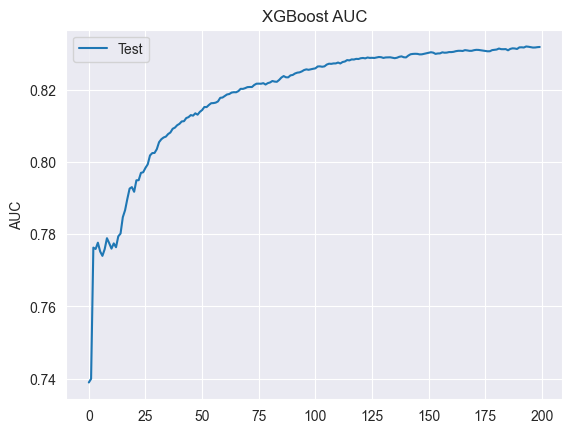

In [282]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 3,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["max_depth"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

[0]	train-auc:0.81665	eval-auc:0.76001
[1]	train-auc:0.81716	eval-auc:0.75824
[2]	train-auc:0.81912	eval-auc:0.76342
[3]	train-auc:0.82120	eval-auc:0.76444
[4]	train-auc:0.83222	eval-auc:0.78108
[5]	train-auc:0.83355	eval-auc:0.77949
[6]	train-auc:0.84559	eval-auc:0.78658
[7]	train-auc:0.84676	eval-auc:0.78825
[8]	train-auc:0.84972	eval-auc:0.78774
[9]	train-auc:0.85094	eval-auc:0.78856
[10]	train-auc:0.85200	eval-auc:0.78796
[11]	train-auc:0.85416	eval-auc:0.79152
[12]	train-auc:0.85518	eval-auc:0.79112
[13]	train-auc:0.85693	eval-auc:0.79145
[14]	train-auc:0.85914	eval-auc:0.79447
[15]	train-auc:0.86095	eval-auc:0.79509
[16]	train-auc:0.86292	eval-auc:0.79721
[17]	train-auc:0.86323	eval-auc:0.79662
[18]	train-auc:0.86425	eval-auc:0.79611
[19]	train-auc:0.86485	eval-auc:0.79626
[20]	train-auc:0.86631	eval-auc:0.79610
[21]	train-auc:0.86780	eval-auc:0.79904
[22]	train-auc:0.86855	eval-auc:0.79927
[23]	train-auc:0.86959	eval-auc:0.79969
[24]	train-auc:0.87136	eval-auc:0.80037
[25]	train

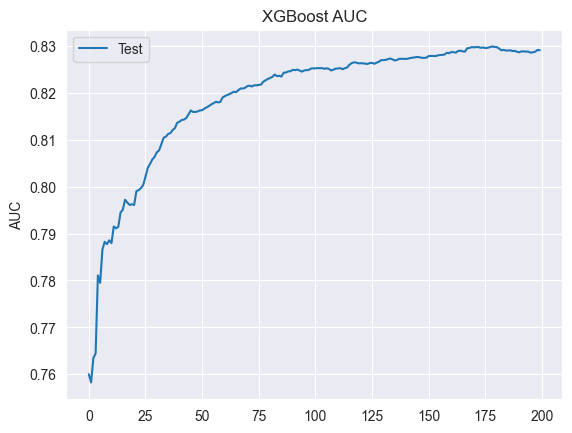

In [283]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 4,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["max_depth"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

[0]	train-auc:0.91921	eval-auc:0.77250
[1]	train-auc:0.92966	eval-auc:0.76963
[2]	train-auc:0.93331	eval-auc:0.76813
[3]	train-auc:0.93868	eval-auc:0.77524
[4]	train-auc:0.94219	eval-auc:0.77782
[5]	train-auc:0.94452	eval-auc:0.77773
[6]	train-auc:0.95268	eval-auc:0.78678
[7]	train-auc:0.95757	eval-auc:0.78775
[8]	train-auc:0.96087	eval-auc:0.78889
[9]	train-auc:0.96322	eval-auc:0.78809
[10]	train-auc:0.96470	eval-auc:0.78774
[11]	train-auc:0.96610	eval-auc:0.78701
[12]	train-auc:0.96763	eval-auc:0.78565
[13]	train-auc:0.96914	eval-auc:0.78529
[14]	train-auc:0.97036	eval-auc:0.78655
[15]	train-auc:0.97174	eval-auc:0.78665
[16]	train-auc:0.97298	eval-auc:0.78788
[17]	train-auc:0.97420	eval-auc:0.78979
[18]	train-auc:0.97573	eval-auc:0.79171
[19]	train-auc:0.97655	eval-auc:0.79151
[20]	train-auc:0.97819	eval-auc:0.79331
[21]	train-auc:0.97923	eval-auc:0.79476
[22]	train-auc:0.98060	eval-auc:0.79587
[23]	train-auc:0.98169	eval-auc:0.79771
[24]	train-auc:0.98254	eval-auc:0.79898
[25]	train

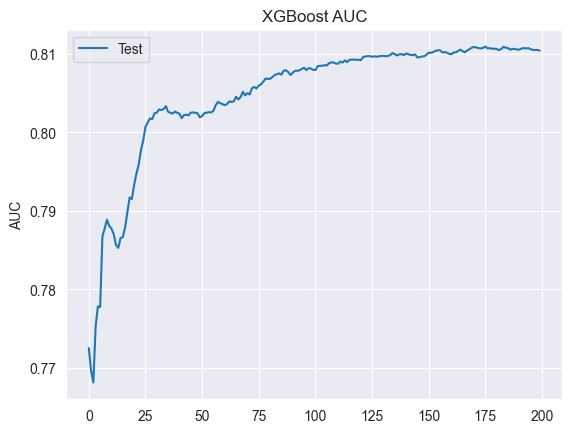

In [284]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 10,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["max_depth"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

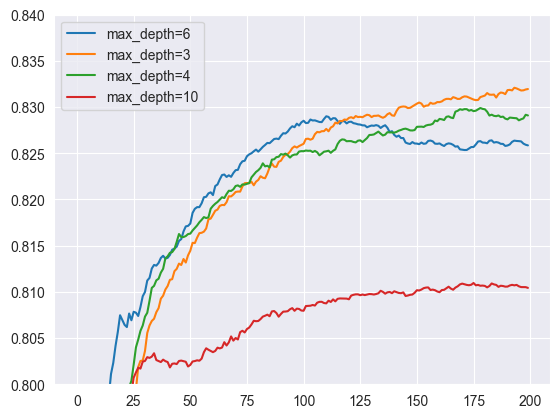

In [287]:
for key, df_scores in scores.items():
    plt.plot(df_scores["num_iterations"], df_scores["test_auc"], label=f"max_depth={key}")
plt.ylim(0.8, 0.84)
plt.legend()

In [ ]:
# According to graph, the value of 10 is the worst

In [288]:
for key, df_scores in scores.items():
    for i in range(len(df_scores["num_iterations"])):
        if df_scores["test_auc"][i] > max_auc:
            max_auc = df_scores["test_auc"][i]
            best_value = key, max_auc, i + 1
best_value

(3, np.float64(0.8320911336610883), 194)

In [289]:
# The best value for max_depth = 3

In [290]:
scores = {}

In [ ]:
# Tuning the min_child_weight

[0]	train-auc:0.77610	eval-auc:0.73891
[1]	train-auc:0.77718	eval-auc:0.73992
[2]	train-auc:0.81066	eval-auc:0.77631
[3]	train-auc:0.81005	eval-auc:0.77593
[4]	train-auc:0.82562	eval-auc:0.77768
[5]	train-auc:0.82506	eval-auc:0.77525
[6]	train-auc:0.82719	eval-auc:0.77402
[7]	train-auc:0.83133	eval-auc:0.77588
[8]	train-auc:0.83229	eval-auc:0.77892
[9]	train-auc:0.83233	eval-auc:0.77753
[10]	train-auc:0.83304	eval-auc:0.77603
[11]	train-auc:0.83526	eval-auc:0.77748
[12]	train-auc:0.83557	eval-auc:0.77641
[13]	train-auc:0.83787	eval-auc:0.77943
[14]	train-auc:0.83983	eval-auc:0.78021
[15]	train-auc:0.84478	eval-auc:0.78474
[16]	train-auc:0.84546	eval-auc:0.78669
[17]	train-auc:0.84857	eval-auc:0.78983
[18]	train-auc:0.84984	eval-auc:0.79268
[19]	train-auc:0.85083	eval-auc:0.79309
[20]	train-auc:0.85103	eval-auc:0.79179
[21]	train-auc:0.85300	eval-auc:0.79498
[22]	train-auc:0.85351	eval-auc:0.79501
[23]	train-auc:0.85394	eval-auc:0.79704
[24]	train-auc:0.85496	eval-auc:0.79722
[25]	train

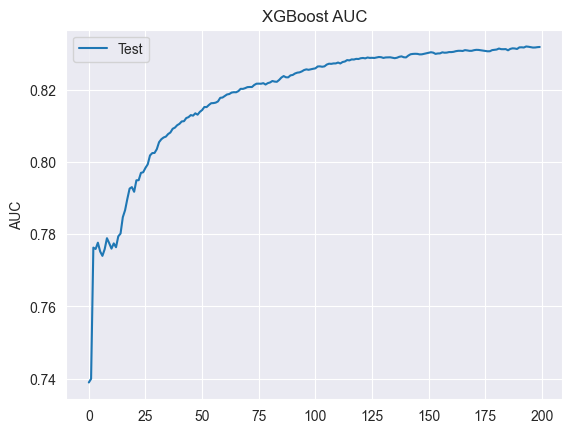

In [291]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 3,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["min_child_weight"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

[0]	train-auc:0.77424	eval-auc:0.73571
[1]	train-auc:0.77424	eval-auc:0.73571
[2]	train-auc:0.80909	eval-auc:0.77323
[3]	train-auc:0.80920	eval-auc:0.77413
[4]	train-auc:0.81945	eval-auc:0.77354
[5]	train-auc:0.82508	eval-auc:0.77370
[6]	train-auc:0.82330	eval-auc:0.77234
[7]	train-auc:0.82515	eval-auc:0.77429
[8]	train-auc:0.82619	eval-auc:0.77296
[9]	train-auc:0.82898	eval-auc:0.77508
[10]	train-auc:0.82956	eval-auc:0.77250
[11]	train-auc:0.82974	eval-auc:0.77345
[12]	train-auc:0.83247	eval-auc:0.77639
[13]	train-auc:0.83475	eval-auc:0.77859
[14]	train-auc:0.84005	eval-auc:0.78297
[15]	train-auc:0.84170	eval-auc:0.78357
[16]	train-auc:0.84464	eval-auc:0.78733
[17]	train-auc:0.84556	eval-auc:0.78867
[18]	train-auc:0.84650	eval-auc:0.78929
[19]	train-auc:0.84814	eval-auc:0.79198
[20]	train-auc:0.84860	eval-auc:0.79089
[21]	train-auc:0.84952	eval-auc:0.79115
[22]	train-auc:0.85013	eval-auc:0.79143
[23]	train-auc:0.85071	eval-auc:0.79250
[24]	train-auc:0.85320	eval-auc:0.79668
[25]	train

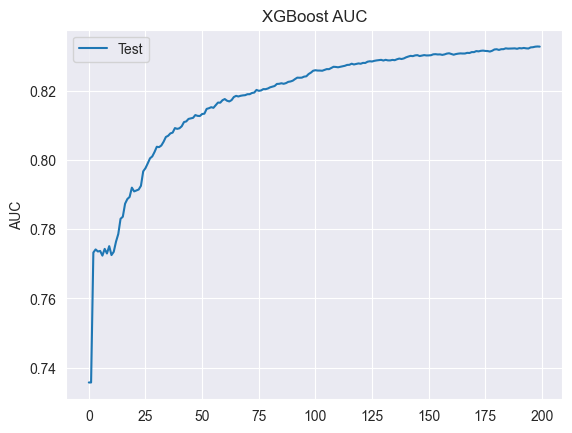

In [292]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 3,  # size of a tree
    "min_child_weight": 10,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["min_child_weight"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

[0]	train-auc:0.76455	eval-auc:0.73369
[1]	train-auc:0.76455	eval-auc:0.73369
[2]	train-auc:0.79960	eval-auc:0.76909
[3]	train-auc:0.79950	eval-auc:0.76877
[4]	train-auc:0.81429	eval-auc:0.76964
[5]	train-auc:0.81529	eval-auc:0.76830
[6]	train-auc:0.81670	eval-auc:0.76781
[7]	train-auc:0.82026	eval-auc:0.76896
[8]	train-auc:0.82295	eval-auc:0.77068
[9]	train-auc:0.82165	eval-auc:0.77111
[10]	train-auc:0.82413	eval-auc:0.77445
[11]	train-auc:0.82680	eval-auc:0.77443
[12]	train-auc:0.82977	eval-auc:0.77784
[13]	train-auc:0.83115	eval-auc:0.77700
[14]	train-auc:0.83414	eval-auc:0.77973
[15]	train-auc:0.83428	eval-auc:0.78116
[16]	train-auc:0.83592	eval-auc:0.78076
[17]	train-auc:0.83924	eval-auc:0.78428
[18]	train-auc:0.83880	eval-auc:0.78458
[19]	train-auc:0.84138	eval-auc:0.78880
[20]	train-auc:0.84285	eval-auc:0.79008
[21]	train-auc:0.84353	eval-auc:0.79144
[22]	train-auc:0.84501	eval-auc:0.79268
[23]	train-auc:0.84633	eval-auc:0.79485
[24]	train-auc:0.84658	eval-auc:0.79539
[25]	train

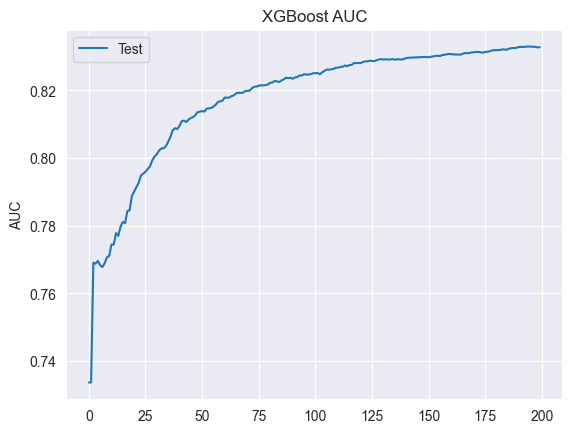

In [293]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 3,  # size of a tree
    "min_child_weight": 30,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=200,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()
scores[xgb_params["min_child_weight"]] = pd.DataFrame(
    [(i, results["train"]["auc"][i], results["eval"]["auc"][i]) for i, _ in enumerate(results["train"]["auc"])],
    columns=["num_iterations", "train_auc", "test_auc"])

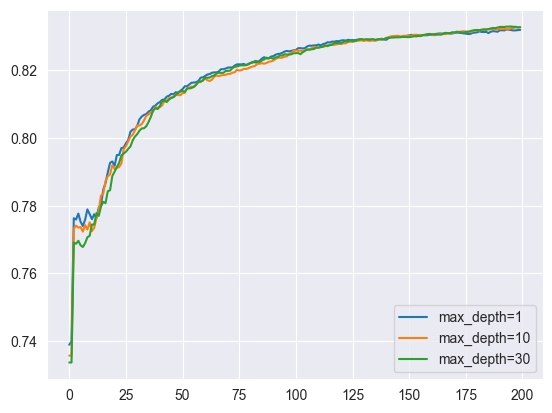

In [294]:
for key, df_scores in scores.items():
    plt.plot(df_scores["num_iterations"], df_scores["test_auc"], label=f"max_depth={key}")
plt.legend()

In [ ]:
# This parameter does not make a huge difference compared to other parameters

[0]	train-auc:0.77610	eval-auc:0.73891
[1]	train-auc:0.77718	eval-auc:0.73992
[2]	train-auc:0.81066	eval-auc:0.77631
[3]	train-auc:0.81005	eval-auc:0.77593
[4]	train-auc:0.82562	eval-auc:0.77768
[5]	train-auc:0.82506	eval-auc:0.77525
[6]	train-auc:0.82719	eval-auc:0.77402
[7]	train-auc:0.83133	eval-auc:0.77588
[8]	train-auc:0.83229	eval-auc:0.77892
[9]	train-auc:0.83233	eval-auc:0.77753
[10]	train-auc:0.83304	eval-auc:0.77603
[11]	train-auc:0.83526	eval-auc:0.77748
[12]	train-auc:0.83557	eval-auc:0.77641
[13]	train-auc:0.83787	eval-auc:0.77943
[14]	train-auc:0.83983	eval-auc:0.78021
[15]	train-auc:0.84478	eval-auc:0.78474
[16]	train-auc:0.84546	eval-auc:0.78669
[17]	train-auc:0.84857	eval-auc:0.78983
[18]	train-auc:0.84984	eval-auc:0.79268
[19]	train-auc:0.85083	eval-auc:0.79309
[20]	train-auc:0.85103	eval-auc:0.79179
[21]	train-auc:0.85300	eval-auc:0.79498
[22]	train-auc:0.85351	eval-auc:0.79501
[23]	train-auc:0.85394	eval-auc:0.79704
[24]	train-auc:0.85496	eval-auc:0.79722
[25]	train

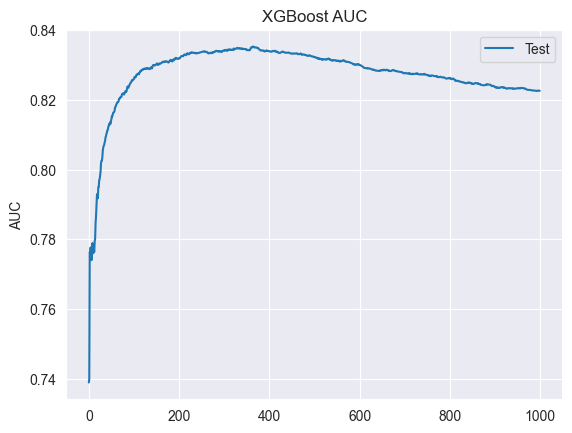

In [312]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 3,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=1000,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()

In [313]:
best_result = max(results["eval"]["auc"]), results["eval"]["auc"].index(max(results["eval"]["auc"]))

In [314]:
best_result

(0.8353545566830545, 363)

In [315]:
# Best number of iterations is 363

[0]	train-auc:0.77610	eval-auc:0.73891
[1]	train-auc:0.77718	eval-auc:0.73992
[2]	train-auc:0.81066	eval-auc:0.77631
[3]	train-auc:0.81005	eval-auc:0.77593
[4]	train-auc:0.82562	eval-auc:0.77768
[5]	train-auc:0.82506	eval-auc:0.77525
[6]	train-auc:0.82719	eval-auc:0.77402
[7]	train-auc:0.83133	eval-auc:0.77588
[8]	train-auc:0.83229	eval-auc:0.77892
[9]	train-auc:0.83233	eval-auc:0.77753
[10]	train-auc:0.83304	eval-auc:0.77603
[11]	train-auc:0.83526	eval-auc:0.77748
[12]	train-auc:0.83557	eval-auc:0.77641
[13]	train-auc:0.83787	eval-auc:0.77943
[14]	train-auc:0.83983	eval-auc:0.78021
[15]	train-auc:0.84478	eval-auc:0.78474
[16]	train-auc:0.84546	eval-auc:0.78669
[17]	train-auc:0.84857	eval-auc:0.78983
[18]	train-auc:0.84984	eval-auc:0.79268
[19]	train-auc:0.85083	eval-auc:0.79309
[20]	train-auc:0.85103	eval-auc:0.79179
[21]	train-auc:0.85300	eval-auc:0.79498
[22]	train-auc:0.85351	eval-auc:0.79501
[23]	train-auc:0.85394	eval-auc:0.79704
[24]	train-auc:0.85496	eval-auc:0.79722
[25]	train

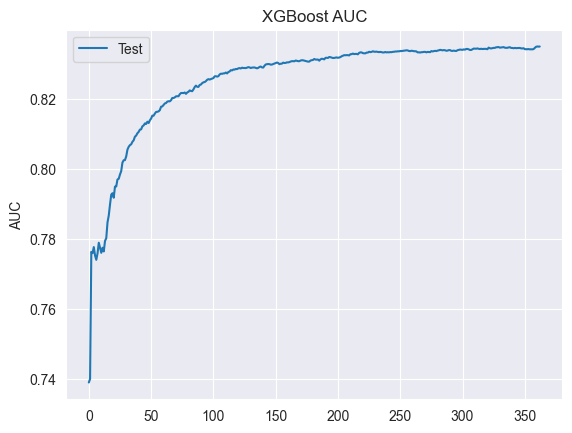

In [316]:
evals_result = {}
xgb_params = {
    "eta": 0.05,  # the learning rate
    "max_depth": 3,  # size of a tree
    "min_child_weight": 1,  # number of observations in leaf node
    "objective": "binary:logistic",  # specify the objective of boosting - binary classification and logistic regression
    "eval_metric": "auc",  # xgb finds the best parameters when training as we give it the metric to match
    "nthread": 12,  # number of threads to use during training
    "seed": 1,  # random seed
    "verbosity": 1  # level of logger - 0 - error, 3 is a debug
}
model = xgb.train(params=xgb_params, dtrain=dtrain, evals=watchlist, evals_result=evals_result, num_boost_round=363,
                  verbose_eval=1)
# Plotting the model result
results = evals_result
epochs = len(results["train"]["auc"])
x_axis = range(0, epochs)
fig, ax = plt.subplots()
# ax.plot(x_axis, results["train"]["auc"], label="Train")
ax.plot(x_axis, results["eval"]["auc"], label="Test")
ax.legend()
ax.xaxis.get_major_locator().set_params(integer=True)
plt.ylabel("AUC")
plt.title("XGBoost AUC")
plt.show()

In [317]:
# Our final model